In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

file_rotterdamPortData = r'..\data\rotterdam_dataset_16.xlsx'
wd = pd.read_excel(file_rotterdamPortData)
wd.info()
wd.head()

<class 'pandas.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Arrival_Date   11076 non-null  datetime64[us]
 1   Vessel_ID      11076 non-null  str           
 2   Vessel_Type    11076 non-null  str           
 3   Cargo_tons     11076 non-null  int64         
 4   Berth_Time_hr  11076 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 432.8 KB


,Arrival_Date,Vessel_ID,Vessel_Type,Cargo_tons,Berth_Time_hr
0,2022-01-01 23:51:00,V000001,Container,18379,17.2
1,2022-01-01 15:07:00,V000002,Container,22886,20.2
2,2022-01-01 08:29:00,V000003,Container,13054,19.3
3,2022-01-01 21:33:00,V000004,Tanker,40882,35.7
4,2022-01-01 09:07:00,V000005,Bulk,45645,27.2


In [21]:
# Analyse the average arrival rates
wd_sorted = wd.sort_values('Arrival_Date').reset_index(drop=True)
n_days = (wd['Arrival_Date'].max() - wd['Arrival_Date'].min()).days

counts = wd['Vessel_Type'].value_counts().sort_index()
rates = (counts / n_days).round(3)

table1 = pd.DataFrame({'Count': counts, 'Rate (vessels/day)': rates})
table1.loc['Total'] = [counts.sum(), round(counts.sum() / n_days, 3)]
print(table1)

               Count  Rate (vessels/day)
Vessel_Type                             
Bulk          2515.0               2.297
Container     6117.0               5.586
Tanker        2444.0               2.232
Total        11076.0              10.115


In [22]:
# Analyse the inter-arrival rates
ia = wd_sorted['Arrival_Date'].diff().dt.total_seconds() / 3600 
ia = ia.dropna() # drop the NaN 

print(ia.describe().round(3))
print("CV:", round(ia.std() / ia.mean(), 3))


# the CV is very close to 1.0 possibly poission process

count    11075.000
mean         2.374
std          2.397
min          0.000
25%          0.667
50%          1.633
75%          3.317
max         21.367
Name: Arrival_Date, dtype: float64
CV: 1.01


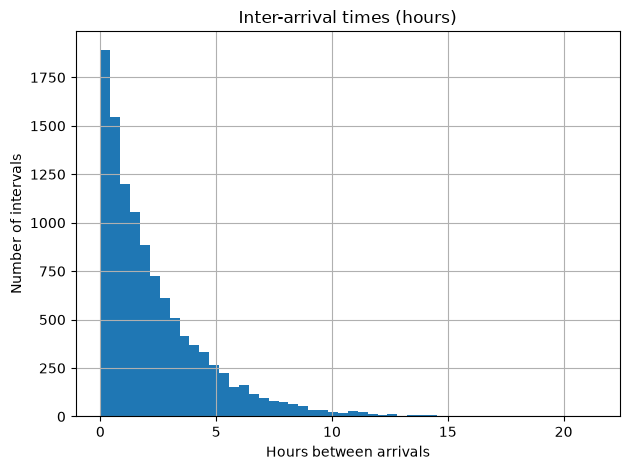

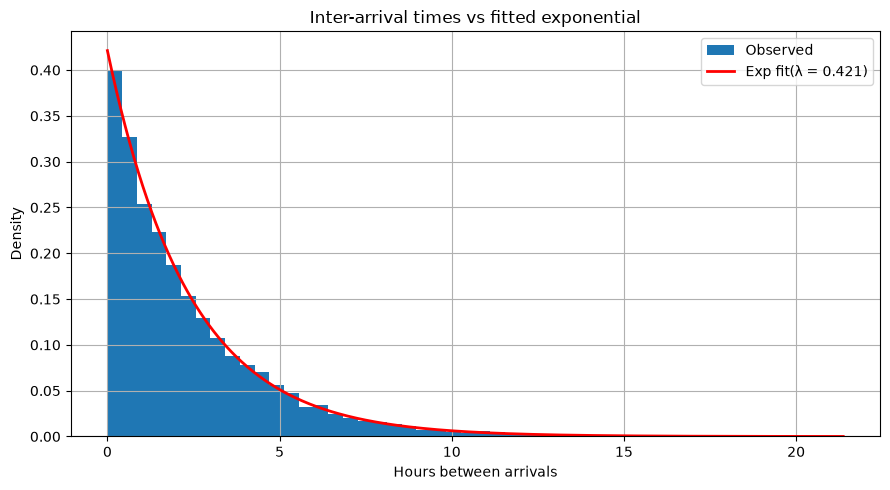

In [23]:

# Histogram of inter-arrival times -- investigate distribution
ia.hist(bins=50)
plt.title('Inter-arrival times (hours)')
plt.xlabel('Hours between arrivals')
plt.ylabel('Number of intervals')

# np.log(ia).hist(bins=40, ax=ax[1])
# ax[1].set_title('log(inter-arrival times)')
# ax[1].set_xlabel('log(hours)')
# ax[1].set_ylabel('Number of intervals')

# fit of exponential distribution
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
ia.hist(bins=50, density=True, ax=ax, label='Observed')

lam_hat = 1 / ia.mean()
x = np.linspace(0, ia.max(), 500)
ax.plot(x, stats.expon.pdf(x, scale=1/lam_hat), 'r-', lw=2, label=f'Exp fit(λ = {lam_hat:.3f})')
ax.set_title('Inter-arrival times vs fitted exponential')
ax.set_xlabel('Hours between arrivals')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()



In [24]:
# using log straightly gives divide by 0 error
# investigate why this happens

print("Zeros in ia: ", (ia == 0).sum())
print("Values under 0.01 h", (ia < 0.01).sum())
print(ia[ia == 0].head())
wd_sorted["gap_hr"] = wd_sorted["Arrival_Date"].diff().dt.total_seconds() / 3600

zero_idx = wd_sorted[wd_sorted['gap_hr'] == 0].index

# Show each zero row and its predecessor
for i in zero_idx[:10]:
    pair = wd_sorted.loc[[i-1, i], ['Arrival_Date', 'Vessel_ID', 'Vessel_Type', 'Cargo_tons']]
    print(pair)
    print("-" * 60)

Zeros in ia:  44
Values under 0.01 h 44
121     0.0
918     0.0
1173    0.0
1695    0.0
1893    0.0
Name: Arrival_Date, dtype: float64
           Arrival_Date Vessel_ID Vessel_Type  Cargo_tons
120 2022-01-15 04:56:00   V000123   Container        8905
121 2022-01-15 04:56:00   V000121   Container       22441
------------------------------------------------------------
           Arrival_Date Vessel_ID Vessel_Type  Cargo_tons
917 2022-04-09 00:19:00   V000918   Container        5514
918 2022-04-09 00:19:00   V000923        Bulk       17277
------------------------------------------------------------
            Arrival_Date Vessel_ID Vessel_Type  Cargo_tons
1172 2022-05-06 01:08:00   V001173   Container       12224
1173 2022-05-06 01:08:00   V001181        Bulk       38725
------------------------------------------------------------
            Arrival_Date Vessel_ID Vessel_Type  Cargo_tons
1694 2022-06-18 09:19:00   V001701        Bulk       41931
1695 2022-06-18 09:19:00   V001700     

In [25]:
# Analyse variability

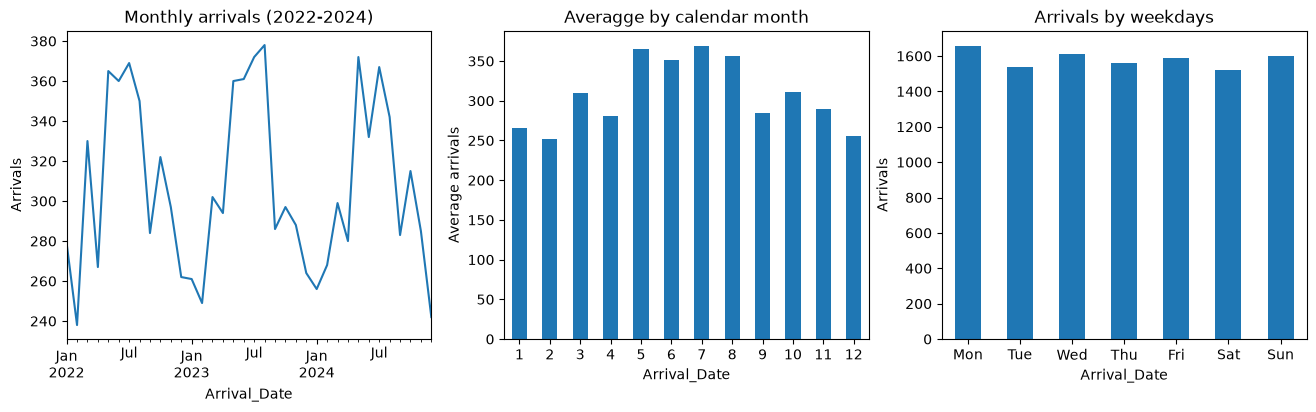

In [26]:
# Analyse seasonal effects

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

monthly = wd.set_index('Arrival_Date').resample('MS').size()
monthly.plot(ax=ax[0])
ax[0].set_title('Monthly arrivals (2022-2024)')
ax[0].set_ylabel('Arrivals')

monthly_avg = wd.groupby(wd['Arrival_Date'].dt.month).size() / 3
monthly_avg.plot(kind='bar', ax=ax[1])
ax[1].set_title('Averagge by calendar month')
ax[1].set_ylabel('Average arrivals')
ax[1].tick_params(axis='x', rotation=0)

weekday = wd.groupby(wd['Arrival_Date'].dt.strftime('%a')).size().reindex(
    ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
)
weekday.plot(kind='bar', ax=ax[2])
ax[2].set_title('Arrivals by weekdays')
ax[2].set_ylabel('Arrivals')
ax[2].tick_params(axis='x', rotation=0)



Text(0, 0.5, 'Arrival')

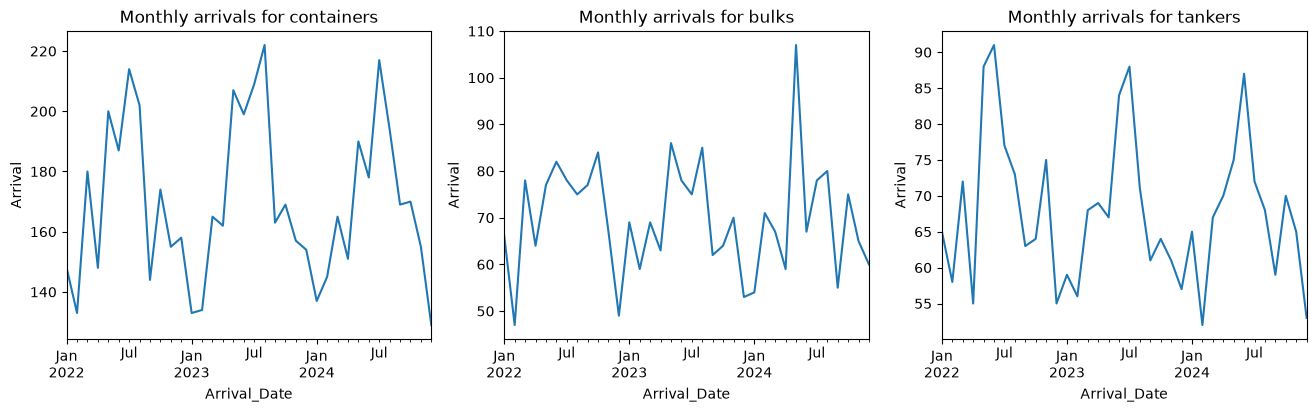

In [37]:
# Analyse difference between vessel categories
fig, ax = plt.subplots(1, 3, figsize=(16,4))
container = wd[wd['Vessel_Type'] == 'Container']

container_monthly = container.set_index('Arrival_Date').resample('MS').size()
container_monthly.plot(ax=ax[0])
ax[0].set_title('Monthly arrivals for containers')
ax[0].set_xlabel('Arrival_Date')
ax[0].set_ylabel('Arrival')


bulk = wd[wd['Vessel_Type'] == 'Bulk']
bulk_monthly = bulk.set_index('Arrival_Date').resample('MS').size()
bulk_monthly.plot(ax=ax[1])
ax[1].set_title('Monthly arrivals for bulks')
ax[1].set_xlabel('Arrival_Date')
ax[1].set_ylabel('Arrival')

tanker = wd[wd['Vessel_Type'] == 'Tanker']
tanker_monthly = tanker.set_index('Arrival_Date').resample('MS').size()
tanker_monthly.plot(ax=ax[2])
ax[2].set_title('Monthly arrivals for tankers')
ax[2].set_xlabel('Arrival_Date')
ax[2].set_ylabel('Arrival')

In [ ]:
# check if there are month with no vessel 
month_per_year = wd.groupby(wd['Arrival_Date'].dt.year)['Arrival_Date'].apply(
    lambda x : x.dt.month.nunique()
)
print(month_per_year)

Arrival_Date
2022    12
2023    12
2024    12
Name: Arrival_Date, dtype: int64
